In [1]:
import pandas as pd

news = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

news.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [2]:
news.info()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


In [3]:
news["date"] = pd.to_datetime(news["date"])

ValueError: time data "2020-05-22 00:00:00" doesn't match format "%Y-%m-%d %H:%M:%S%z". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [4]:
news["date"] = pd.to_datetime(news["date"], format="mixed", errors="coerce")

ValueError: Mixed timezones detected. Pass utc=True in to_datetime or tz='UTC' in DatetimeIndex to convert to a common timezone.

In [5]:
news["date"] = pd.to_datetime(news["date"], utc=True, errors="coerce")

In [6]:
news.shape

(1407328, 6)

In [7]:
news.isnull().sum()

Unnamed: 0          0
headline            0
url                 0
publisher           0
date          1351341
stock               0
dtype: int64

In [8]:
news["date"].head(20)

0    2020-06-05 14:30:54+00:00
1    2020-06-03 14:45:20+00:00
2    2020-05-26 08:30:07+00:00
3    2020-05-22 16:45:06+00:00
4    2020-05-22 15:38:59+00:00
5    2020-05-22 15:23:25+00:00
6    2020-05-22 13:36:20+00:00
7    2020-05-22 13:07:04+00:00
8    2020-05-22 12:37:59+00:00
9    2020-05-22 12:06:17+00:00
10                         NaT
11                         NaT
12                         NaT
13                         NaT
14                         NaT
15                         NaT
16                         NaT
17                         NaT
18                         NaT
19                         NaT
Name: date, dtype: datetime64[us, UTC]

In [9]:
news["date"].unique()[:10]

<DatetimeArray>
['2020-06-05 14:30:54+00:00', '2020-06-03 14:45:20+00:00',
 '2020-05-26 08:30:07+00:00', '2020-05-22 16:45:06+00:00',
 '2020-05-22 15:38:59+00:00', '2020-05-22 15:23:25+00:00',
 '2020-05-22 13:36:20+00:00', '2020-05-22 13:07:04+00:00',
 '2020-05-22 12:37:59+00:00', '2020-05-22 12:06:17+00:00']
Length: 10, dtype: datetime64[us, UTC]

In [10]:
news.shape

(1407328, 6)

In [11]:
missing_percentage = news["date"].isnull().mean() * 100
missing_percentage

np.float64(96.02175185884172)

In [12]:
news["date"] = pd.to_datetime(news["date"], errors="coerce")

In [13]:
news.isnull().sum()

Unnamed: 0          0
headline            0
url                 0
publisher           0
date          1351341
stock               0
dtype: int64

In [14]:
news[news["date"].isnull()].head()

,Unnamed: 0,headline,url,publisher,date,stock
10,10,30 Stocks Moving in Friday's Pre-Market Session,https://www.benzinga.com/news/20/05/16092879/3...,Lisa Levin,NaT,A
11,11,SVB Leerink Maintains Outperform on Agilent Te...,https://www.benzinga.com/news/20/05/16092270/s...,vishwanath@benzinga.com,NaT,A
12,12,8 Stocks Moving In Thursday's After-Hours Session,https://www.benzinga.com/news/20/05/16089803/8...,Tyree Gorges,NaT,A
13,13,Agilent Technologies shares are trading higher...,https://www.benzinga.com/wiim/20/05/16089218/a...,Benzinga Newsdesk,NaT,A
14,14,Agilent Technologies Q2 Adj. EPS $0.71 Beats $...,https://www.benzinga.com/news/earnings/20/05/1...,Benzinga Newsdesk,NaT,A


In [15]:
news = news.dropna(subset=["date"])

In [16]:
news.isnull().sum()

Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

In [17]:
news = news.drop(columns=["Unnamed: 0"])

In [18]:
news.info()

<class 'pandas.DataFrame'>
Index: 55987 entries, 0 to 1407270
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype              
---  ------     --------------  -----              
 0   headline   55987 non-null  str                
 1   url        55987 non-null  str                
 2   publisher  55987 non-null  str                
 3   date       55987 non-null  datetime64[us, UTC]
 4   stock      55987 non-null  str                
dtypes: datetime64[us, UTC](1), str(4)
memory usage: 2.6 MB


In [19]:
news["headline_length"] = news["headline"].str.len()

In [20]:
news["headline_length"].describe()

count    55987.000000
mean        80.015254
std         56.126094
min         12.000000
25%         42.000000
50%         63.000000
75%         91.000000
max        512.000000
Name: headline_length, dtype: float64

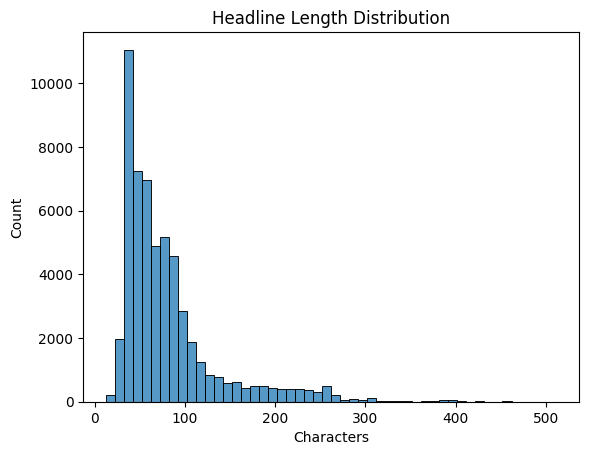

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(news["headline_length"], bins=50)
plt.title("Headline Length Distribution")
plt.xlabel("Characters")
plt.show()

In [22]:
publisher_counts = news["publisher"].value_counts()

publisher_counts.head(10)

publisher
Benzinga Newsdesk    14750
Lisa Levin           12408
ETF Professor         4362
Paul Quintaro         4212
Benzinga Newsdesk     3177
Benzinga Insights     2332
Vick Meyer            2128
Charles Gross         1790
Hal Lindon            1470
Benzinga_Newsdesk     1239
Name: count, dtype: int64

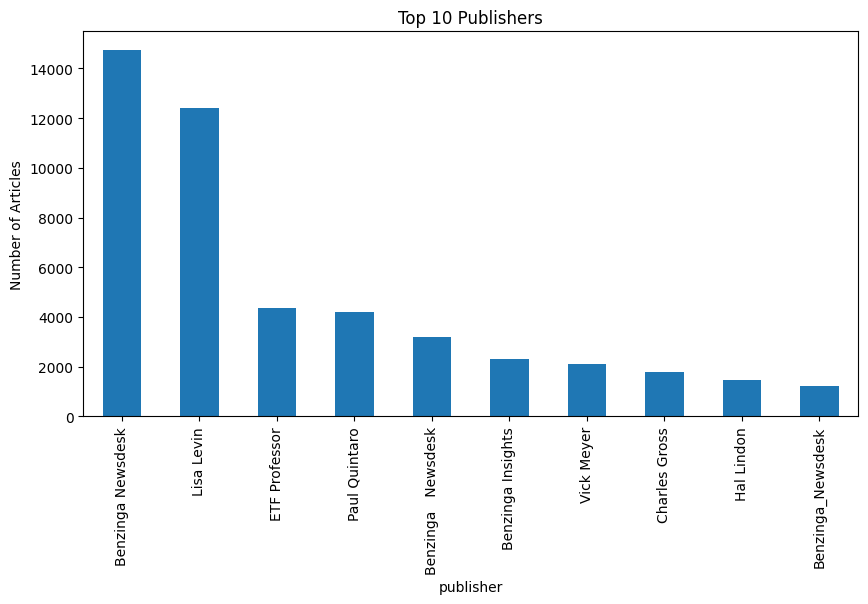

In [23]:
publisher_counts.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Publishers")
plt.ylabel("Number of Articles")
plt.show()

In [24]:
news["date_only"] = news["date"].dt.date

In [25]:
daily_news = news.groupby("date_only").size()

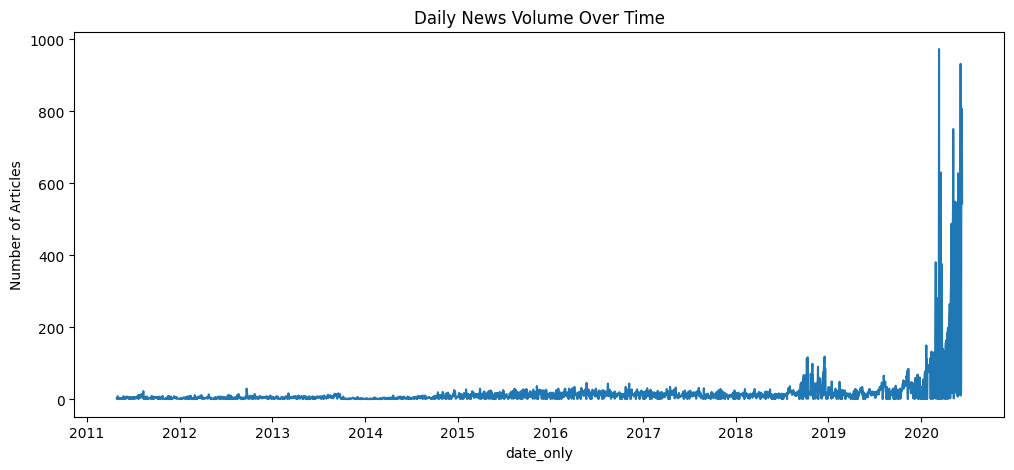

In [26]:
daily_news.plot(figsize=(12,5))
plt.title("Daily News Volume Over Time")
plt.ylabel("Number of Articles")
plt.show()

In [27]:
news["hour"] = news["date"].dt.hour

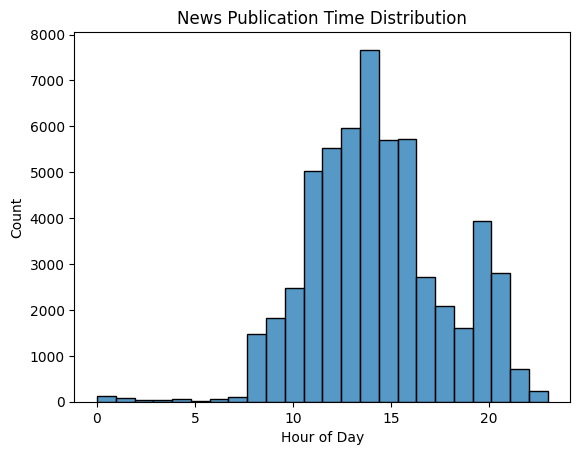

In [28]:
sns.histplot(news["hour"], bins=24)
plt.title("News Publication Time Distribution")
plt.xlabel("Hour of Day")
plt.show()

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english")

X = vectorizer.fit_transform(news["headline"])

words = vectorizer.get_feature_names_out()

In [30]:
import numpy as np

scores = np.array(X.sum(axis=0)).flatten()

keywords = pd.DataFrame({
    "word": words,
    "score": scores
}).sort_values(by="score", ascending=False)

keywords.head(20)

,word,score
19250,stocks,3073.885256
21504,week,2661.314459
1739,52,2659.869825
10999,hit,2358.705777
13090,lows,1703.170220
20072,thursday,1324.086125
10953,highs,1245.569749
9896,friday,1119.673312
13383,market,1100.224252
18370,shares,1067.788529


In [31]:
stock_counts = news["stock"].value_counts()

stock_counts

stock
A        10
AA       10
AAC      10
AAL      10
AAMC     10
         ..
XXV       1
YMLI      1
YYY       1
ZIONW     1
ZMLP      1
Name: count, Length: 6204, dtype: int64

In [ ]:
stock_counts.plot(kind="bar")
plt.title("News Coverage by Stock")
plt.ylabel("Number of Articles")
plt.show()